<a href="https://colab.research.google.com/github/alwhshalkasr267-design/FinalProject/blob/main/finalproject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
zip_path = '/content/drive/MyDrive/Obstacles_dataset.zip'
extracted_path = '/content/dataset/Obstacles_dataset'

if not os.path.exists(extracted_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    print("تم فك ضغط البيانات بنجاح في المسار المحلي.")
else:
    print("المجلد موجود مسبقاً.")

المجلد موجود مسبقاً.


Import Required Libraries

In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Load Data

In [55]:
folder_path = '/content/dataset'

if len(os.listdir(folder_path)) == 1:
    folder_path = os.path.join(folder_path, os.listdir(folder_path)[0])

classes_names = sorted(os.listdir(folder_path))
print("Dataset Classes: ", classes_names)

Dataset Classes:  ['chair', 'door', 'fence', 'garbage_bin', 'obstacle', 'plant', 'pothole', 'stairs', 'table', 'vehicle']


In [59]:
# حساب عدد الصور في كل كلاس
i = 1
for folder in sorted(os.listdir(folder_path)):
    full_folder_path = os.path.join(folder_path, folder)
    if os.path.isdir(full_folder_path):
        num_images = len(os.listdir(full_folder_path))
        print(f"{i} Number of [{folder}] Class : {num_images} images")
        i += 1

1 Number of [chair] Class : 407 images
2 Number of [door] Class : 242 images
3 Number of [fence] Class : 179 images
4 Number of [garbage_bin] Class : 175 images
5 Number of [obstacle] Class : 423 images
6 Number of [plant] Class : 139 images
7 Number of [pothole] Class : 706 images
8 Number of [stairs] Class : 504 images
9 Number of [table] Class : 185 images
10 Number of [vehicle] Class : 604 images


In [56]:
images = []
labels = []

for label_idx, classes_name in enumerate(classes_names):
    class_dir = os.path.join(folder_path, classes_name)
    if os.path.isdir(class_dir):
        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            images.append(img_path)
            labels.append(str(label_idx))

In [57]:
df = pd.DataFrame({
    "image": images,
    "label": labels
})

# خلط البيانات
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total images collected: {len(df)}")
df.head()

Total images collected: 3564


,image,label
0,/content/dataset/Obstacles_dataset/stairs/IMG_...,7
1,/content/dataset/Obstacles_dataset/chair/th-11...,0
2,/content/dataset/Obstacles_dataset/pothole/gam...,6
3,/content/dataset/Obstacles_dataset/obstacle/ga...,4
4,/content/dataset/Obstacles_dataset/table/th-35...,8


In [60]:
# تنظيف الصور طبعا الصور عندي نظيفة هشغل الكود فقط عند اخر نقطة
from PIL import Image
from tqdm import tqdm

bad = []

for p in tqdm(df["image"]):
  try:
    with Image.open(p) as im:
      im.load()
  except:
    bad.append(p)

print("Bad images : ", len(bad))

df = df[~df["image"].isin(bad)].reset_index(drop=True)
print("Remaining images : ", len(df) )

100%|██████████| 3564/3564 [00:16<00:00, 214.23it/s]

Bad images :  0
Remaining images :  3564


In [61]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
    )

print("Train: ", len(train_df))
print("Test: ", len(test_df))

Train:  2851
Test:  713


In [62]:
train_gen = ImageDataGenerator(
    rescale=1./255,          # تحجيم قيم البكسلات بين 0 و 1
    rotation_range=20,       # تدوير الصور
    width_shift_range=0.2,   # إزاحة يميناً ويساراً
    height_shift_range=0.2,  # إزاحة لأعلى وأسفل
    shear_range=0.2,         # قص الزوايا (مهم جداً للرؤية الجانبية للعوائق) - مضاف لرفع الدقة
    zoom_range=0.2,          # تكبير/تصغير (مهم لمعرفة البعد والقرب) - مضاف لرفع الدقة
    horizontal_flip=True,    # قلب الصور أفقياً
    fill_mode='nearest'      # تعبئة الفراغات الناتجة عن الإزاحة بشكل ذكي
)
test_gen = ImageDataGenerator(rescale=1./255)

In [63]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_it = train_gen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_it = test_gen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2851 validated image filenames belonging to 10 classes.
Found 713 validated image filenames belonging to 10 classes.


In [65]:
from tensorflow.keras.models import Sequential
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes_names), activation='softmax')
])


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,819,754 (18.39 MB)

 Trainable params: 4,819,306 (18.38 MB)

 Non-trainable params: 448 (1.75 KB)

In [66]:
from tensorflow.keras.callbacks import EarlyStopping

# مراقبة خسارة التحقق وإيقاف التدريب فوراً إذا توقف النموذج عن التحسن
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [71]:
from tensorflow.keras.callbacks import  ModelCheckpoint
# 2. تحديد مسار الحفظ داخل الدرايف
checkpoint_path = "/content/drive/MyDrive/my_model_checkpoint.keras"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,     # حفظ الهيكل والأوزان بالكامل
    monitor='val_accuracy',
    save_best_only=True          # يحفظ فقط إذا تحسنت الدقة عن المرات السابقة
)

In [ ]:
history = model.fit(
    train_it,
    epochs=30,
    validation_data=test_it,
    callbacks=[early_stopping, checkpoint_callback]
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 275s 3s/step - accuracy: 0.2406 - loss: 3.6070 - val_accuracy: 0.1978 - val_loss: 12.2605
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.3016 - loss: 2.0758 - val_accuracy: 0.1431 - val_loss: 6.3093
Epoch 3/30
31/90 ━━━━━━━━━━━━━━━━━━━━ 2:42 3s/step - accuracy: 0.3361 - loss: 1.9181

In [ ]:
# استرجاع النموذج الذي توقف عنده التدريب
my_net2 = tf.keras.models.load_model("/content/drive/MyDrive/my_model_checkpoint.keras")

# الآن يمكنك عمل fit مجدداً وسيبدأ من حيث توقف!

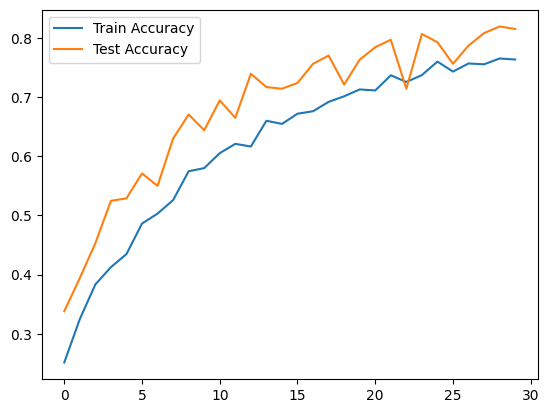

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. تأكد أن التوقعات مأخوذة بشكل صحيح
preds = model.predict(test_it)

# 2. تحويل التوقعات إلى أرقام الكلاسات الصحيحة (Argmax)
# استخدم argmax إذا كان لديك أكثر من كلاسين (Multi-class)
pred_labels = np.argmax(preds, axis=1)

# 3. جلب التسميات الحقيقية
true_labels = test_it.classes

# 4. طباعة النتائج
print("Confusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels))

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step
Confusion Matrix:
[[ 54   4   0   4   0   4   6   2   3   4]
 [  1  43   0   2   0   0   0   0   2   0]
 [  4   1  24   1   1   2   0   2   0   1]
 [  4   3   3  81   7   1   0   0   0   2]
 [  0   0   2   1 135   1   0   0   0   2]
 [  3   0   0   3   6  70   0   0   0   3]
 [  8   0   0   1   0   0  22   0   1   5]
 [  2   0   1   2   0   1   0  22   0   0]
 [  1   1   0   0   0   1   0   0  30   2]
 [  4   1   0   5   5   1   0   0   2 103]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        81
           1       0.81      0.90      0.85        48
           2       0.80      0.67      0.73        36
           3       0.81      0.80      0.81       101
           4       0.88      0.96      0.92       141
           5       0.86      0.82      0.84        85
           6       0.79      0.59      0.68        37
           7       0.85      0.79      0.81        28

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. إعادة تجهيز بيانات الاختبار مع إيقاف الخلط العشوائي (shuffle=False) لضمان تطابق الترتيب
test_it_ordered = datagen.flow_from_dataframe(
    dataframe=test_df,
        directory=None,
            x_col='File_Path',
                y_col='Label',
                    target_size=(150, 150),  # تأكد أنها نفس الأبعاد المستخدمة في مشروعك
                        batch_size=32,
                            class_mode='categorical',
                                shuffle=False             # هذه هي النقطة الجوهرية لمنع الخطأ
                                )

                                # 2. حساب التوقعات بناءً على الترتيب الصحيح
                                preds = model.predict(test_it_ordered)
                                pred_labels = np.argmax(preds, axis=1)

                                # 3. جلب التسميات الحقيقية المرتبة
                                true_labels = test_it_ordered.classes

                                # 4. طباعة تقرير التصنيف النصي (Classification Report)
                                print("Classification Report:\n")
                                print(classification_report(true_labels, pred_labels, target_names=list(categories_dict.keys())))

                                # 5. حساب ورسم مصفوفة الارتباك بشكل مرئي واحترافي (Heatmap)
                                cm = confusion_matrix(true_labels, pred_labels)

                                plt.figure(figsize=(10, 8))
                                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                                            xticklabels=list(categories_dict.keys()),
                                                        yticklabels=list(categories_dict.keys()))
                                                        plt.ylabel('True Labels (القيم الحقيقية)')
                                                        plt.xlabel('Predicted Labels (توقعات النموذج)')
                                                        plt.title('Confusion Matrix Heatmap')
                                                        plt.show()


IndentationError: unexpected indent (172047096.py, line 19)